In [3]:
# ============================================================
# STEP 01: Load Dataset
# ============================================================

import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset folder
folder_path = "/content/New ML Project "

# Find CSV files
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

print("CSV files found:", csv_files)

# Load CSV
csv_file_path = os.path.join(folder_path, csv_files[0])

df = pd.read_csv(csv_file_path)

print("\nDataset loaded successfully!")
print("File:", csv_files[0])

display(df.head())

CSV files found: ['Industrial Fabric Quality Inspection Dataset.csv']

Dataset loaded successfully!
File: Industrial Fabric Quality Inspection Dataset.csv


,thread_count,gsm,tensile_strength,shrinkage_percent,color_fastness,fabric_thickness,defect_count,elongation_percent,moisture_absorption,fabric_type,...,batch_id,roll_number,inspection_time_minutes,warehouse_id,operator_name,inspection_shift,machine_temperature,humidity_level,inspection_notes,fabric_quality
0,166.0,383.0,NaN,7.744704,1,0.891865,11,31.299228,12.855777,polyester,...,898423,363,45.957289,WH-A,Suresh,Morning,28.148868,67.810041,Recheck,Low
1,273.0,107.0,106.508682,1.191272,1,0.872380,4,8.092515,7.224689,polyester,...,350678,4741,33.035982,WH-C,Suresh,Morning,42.033282,40.596520,Looks fine,High
2,274.0,352.0,97.100410,NaN,3,1.231906,3,24.134907,12.276679,silk,...,195742,1626,35.768493,WH-A,Ramesh,Morning,35.450923,37.799588,OK,High
3,NaN,200.0,17.876660,4.001214,1,0.320100,12,18.334479,14.732114,linen,...,940561,894,38.349274,WH-A,Ramesh,Night,23.459327,57.420943,Minor issue,Low
4,115.0,348.0,62.746013,2.529863,2,0.903725,14,6.396909,11.692512,cotton,...,740914,2621,44.339097,WH-A,Priya,Evening,33.873426,42.449570,Minor issue,Low


## STEP 02: Dataset Inspection

- Check dataset size.
- Check column names and data types.
- Understand the structure of the dataset.

In [4]:
# ============================================================
# STEP 02: Dataset Inspection
# ============================================================

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (25750, 23)

Column Names:
['thread_count', 'gsm', 'tensile_strength', 'shrinkage_percent', 'color_fastness', 'fabric_thickness', 'defect_count', 'elongation_percent', 'moisture_absorption', 'fabric_type', 'weave_type', 'finish_type', 'production_method', 'batch_id', 'roll_number', 'inspection_time_minutes', 'warehouse_id', 'operator_name', 'inspection_shift', 'machine_temperature', 'humidity_level', 'inspection_notes', 'fabric_quality']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25750 entries, 0 to 25749
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   thread_count             24460 non-null  float64
 1   gsm                      24465 non-null  float64
 2   tensile_strength         24458 non-null  float64
 3   shrinkage_percent        24467 non-null  float64
 4   color_fastness           25750 non-null  int64  
 5   fabric_thickness         2575

## STEP 03: Feature Summary & Missing Values

- Check each feature's data type.
- Count missing values.
- Count unique values.
- Identify features that need cleaning.


In [7]:
# ============================================================
# STEP 03: Feature Summary & Missing Values
# ============================================================

feature_summary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

display(feature_summary)

,Feature,Data Type,Missing Values,Unique Values
0,thread_count,float64,1290,276
1,gsm,float64,1285,316
2,tensile_strength,float64,1292,23750
3,shrinkage_percent,float64,1283,23750
4,color_fastness,int64,0,5
5,fabric_thickness,float64,0,25000
6,defect_count,int64,0,15
7,elongation_percent,float64,0,25001
8,moisture_absorption,float64,0,25000
9,fabric_type,object,1292,18


In [8]:
# ============================================================
# STEP 03A: Missing Value Summary
# ============================================================

missing_summary = df.isnull().sum().reset_index()

missing_summary.columns = ["Feature", "Missing Values"]

missing_summary["Missing Percentage"] = (
    missing_summary["Missing Values"] / len(df) * 100
).round(2)

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values("Missing Values", ascending=False)

display(missing_summary)

,Feature,Missing Values,Missing Percentage
18,inspection_shift,1302,5.06
9,fabric_type,1292,5.02
2,tensile_strength,1292,5.02
0,thread_count,1290,5.01
10,weave_type,1287,5.00
1,gsm,1285,4.99
3,shrinkage_percent,1283,4.98


## STEP 04: Duplicate Detection

- Check for completely duplicate rows.
- Identify how many duplicate records are present.
- Remove duplicates before further preprocessing.


In [9]:
# ============================================================
# STEP 04A: Inspect Duplicate Rows
# ============================================================

duplicates = df[df.duplicated(keep=False)]

print("Total rows involved in duplicates:", len(duplicates))

display(duplicates.head(10))


Total rows involved in duplicates: 1484


,thread_count,gsm,tensile_strength,shrinkage_percent,color_fastness,fabric_thickness,defect_count,elongation_percent,moisture_absorption,fabric_type,...,batch_id,roll_number,inspection_time_minutes,warehouse_id,operator_name,inspection_shift,machine_temperature,humidity_level,inspection_notes,fabric_quality
6,193.0,390.0,44.546852,5.873863,1,1.070468,5,25.631420,11.032973,linen,...,852901,2451,17.803688,WH-C,Suresh,Morning,44.270253,40.644037,Approved,Medium
8,95.0,91.0,21.106486,1.694754,4,0.400065,14,6.868279,9.054425,polyester,...,232045,1891,29.929684,WH-B,Suresh,Morning,42.864560,78.643183,Recheck,High
21,162.0,380.0,45.822144,2.712674,3,0.947618,7,35.395100,14.282969,silk,...,453016,3960,11.320092,WH-C,John,Night,39.371285,49.776751,Minor issue,Medium
32,124.0,199.0,112.218126,5.521800,2,0.626958,2,11.118222,7.585572,cotton,...,460107,4990,44.089256,WH-C,Ramesh,Morning,25.079048,67.153211,Looks fine,High
38,230.0,345.0,51.664724,6.844537,5,0.850325,14,33.669890,3.795752,wool,...,743747,4247,53.448506,WH-B,Ramesh,Morning,34.691344,39.978469,OK,Low
41,NaN,396.0,56.181366,2.250206,2,0.157732,14,24.910973,4.634700,silk,...,613881,110,31.579279,WH-A,Anita,Morning,23.990316,68.303858,OK,Low
42,158.0,274.0,119.342206,7.983226,1,0.197504,10,8.122497,11.943797,silk,...,471311,2518,36.275999,WH-C,Suresh,Night,25.517454,45.549744,OK,Low
64,303.0,148.0,84.414954,5.553040,3,0.973106,0,30.711066,4.516617,linen,...,463767,2179,56.034736,WH-C,Anita,Morning,39.322054,81.072502,Minor issue,High
71,159.0,141.0,87.204105,5.747723,3,1.089297,14,31.740212,9.228817,linen,...,798413,1590,10.317764,WH-C,Suresh,Night,43.725313,66.524527,Looks fine,Low
75,198.0,198.0,21.426671,5.024026,1,0.846411,14,35.848025,13.549652,cotton,...,898840,848,34.372698,WH-A,Anita,Night,38.964298,39.323443,Looks fine,Low


 ## STEP 04B: Remove Duplicate Rows

- Remove completely duplicate records.
- Keep the first occurrence of each duplicate.
- Verify the dataset size after removal.

In [10]:
# ============================================================
# STEP 04B: Remove Duplicate Rows
# ============================================================

original_rows = len(df)

df = df.drop_duplicates().reset_index(drop=True)

removed_rows = original_rows - len(df)

print("Original Rows:", original_rows)
print("Rows After Removing Duplicates:", len(df))
print("Rows Removed:", removed_rows)

Original Rows: 25750
Rows After Removing Duplicates: 25008
Rows Removed: 742


In [11]:
# ============================================================
# STEP 04C: Verify Duplicate Removal
# ============================================================

remaining_duplicates = df.duplicated().sum()

print("Remaining Duplicate Rows:", remaining_duplicates)

Remaining Duplicate Rows: 0


### Duplicate Removal Observation

- 742 duplicate rows were identified and removed.
- The dataset now contains 25,008 rows.
- No exact duplicate rows remain after cleaning.


## STEP 05: Missing Value Treatment

- Numerical missing values → Median
- Categorical missing values → Mode
- Verify missing values after treatment


In [12]:
# ============================================================
# STEP 05A: Define Numerical and Categorical Features
# ============================================================

numeric_features = [
    "thread_count",
    "gsm",
    "tensile_strength",
    "shrinkage_percent",
    "color_fastness",
    "fabric_thickness",
    "defect_count",
    "elongation_percent",
    "moisture_absorption",
    "inspection_time_minutes",
    "machine_temperature",
    "humidity_level"
]

categorical_features = [
    "fabric_type",
    "weave_type",
    "finish_type",
    "production_method",
    "warehouse_id",
    "operator_name",
    "inspection_shift",
    "inspection_notes"
]

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 12
Categorical features: 8


In [13]:
# ============================================================
# STEP 05B: Handle Missing Values
# ============================================================

# Numerical features → Median
for col in numeric_features:
    if df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)

# Categorical features → Mode
for col in categorical_features:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col] = df[col].fillna(mode_value)

print("Missing values handled successfully.")

Missing values handled successfully.


In [14]:
# ============================================================
# STEP 05C: Verify Missing Value Treatment
# ============================================================

remaining_missing = df.isnull().sum()

print("Total remaining missing values:", remaining_missing.sum())

display(
    remaining_missing[remaining_missing > 0].to_frame(
        "Missing Values"
    )
)

Total remaining missing values: 0


,Missing Values


### Missing Value Treatment Observation

- Numerical missing values were filled using the median.
- Categorical missing values were filled using the mode.
- After treatment, no missing values remain.

## STEP 06: Categorical Data Analysis

- Identify categorical features and their unique values.
- Decide suitable encoding based on the nature of each feature.
- Avoid applying the same encoding method blindly to all categorical features.

In [15]:
# ============================================================
# STEP 06A: Inspect Categorical Features
# ============================================================

for col in categorical_features:
    print(f"\n{col}")
    print("Unique values:", df[col].unique())
    print("Number of unique values:", df[col].nunique())


fabric_type
Unique values: ['polyester' 'silk' 'linen' 'cotton' 'wool' 'COTTON' '???' '  silk'
 '  cotton  ' 'POLYESTER' 'LINEN' ' Cotton ' 'SILK' ' polyester  '
 'UNKNOWN' ' Silk ' 'cOtToN' ' Linen ']
Number of unique values: 18

weave_type
Unique values: ['twill' 'satin' 'plain' '  satin ' 'PLAIN' ' Plain ' ' Twill ' 'TWILL'
 'SATIN' '  plain ']
Number of unique values: 10

finish_type
Unique values: ['raw' 'dyed' 'printed']
Number of unique values: 3

production_method
Unique values: ['handloom' 'powerloom']
Number of unique values: 2

warehouse_id
Unique values: ['WH-A' 'WH-C' 'WH-B' 'wh-b' ' wh-a ' 'WH-C ']
Number of unique values: 6

operator_name
Unique values: ['Suresh' 'Ramesh' 'Priya' 'John' 'Anita' ' Ramesh ' 'SURESH' 'RAMESH'
 'priya ' 'john' 'PRIYA' ' suresh ' 'JOHN']
Number of unique values: 13

inspection_shift
Unique values: ['Morning' 'Night' 'Evening' 'morning' 'evening' ' Morning ' 'EVENING '
 'NIGHT' 'MORNING' 'night']
Number of unique values: 10

inspection_notes


### STEP 06B: Categorical Data Cleaning

- Remove extra spaces from category values.
- Standardize letter casing.
- Handle invalid/unknown category values.
- Reduce duplicate representations of the same category.

In [17]:
# ============================================================
# STEP 06B: Clean Categorical Values
# ============================================================

# Columns with inconsistent categorical values
clean_categorical_cols = [
    "fabric_type",
    "weave_type",
    "warehouse_id",
    "operator_name",
    "inspection_shift"
]

# Remove extra spaces and standardize case
for col in clean_categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

print("Categorical values standardized successfully.")

Categorical values standardized successfully.


In [18]:
# ============================================================
# STEP 06C: Handle Invalid Categorical Values
# ============================================================

df["fabric_type"] = df["fabric_type"].replace(
    ["???", "unknown"],
    np.nan
)

print("Invalid fabric_type values converted to missing.")

Invalid fabric_type values converted to missing.


In [19]:
# ============================================================
# STEP 06D: Verify Categorical Cleaning
# ============================================================

for col in clean_categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


fabric_type
['polyester' 'silk' 'linen' 'cotton' 'wool' nan]

weave_type
['twill' 'satin' 'plain']

warehouse_id
['wh-a' 'wh-c' 'wh-b']

operator_name
['suresh' 'ramesh' 'priya' 'john' 'anita']

inspection_shift
['morning' 'night' 'evening']


### STEP 06E: Handle Newly Created Missing Values

- Invalid categorical values were converted to missing values.
- Fill the new missing values using the mode.

In [20]:
 # ============================================================
# STEP 06E: Fill Newly Created Missing Values
# ============================================================

for col in clean_categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col] = df[col].fillna(mode_value)

print("New categorical missing values handled successfully.")

New categorical missing values handled successfully.


In [21]:
# ============================================================
# STEP 06F: Verify Missing Values
# ============================================================

print("Total remaining missing values:", df.isnull().sum().sum())

Total remaining missing values: 0


## STEP 07: Label Encoding

- Encode a suitable categorical feature using a dictionary.
- Create the mapping manually.
- Verify the encoded values.

In [22]:
# ============================================================
# STEP 07: LABEL ENCODING FROM SCRATCH
# ============================================================

# Part 1: Check original categories
print("Original production_method values:")
print(df["production_method"].unique())


# Part 2: Create manual label mapping
label_mapping = {
    "handloom": 0,
    "powerloom": 1
}

print("\nLabel Mapping:")
print(label_mapping)


# Part 3: Apply the mapping
df["production_method_encoded"] = df["production_method"].map(label_mapping)


# Part 4: Display original and encoded values
print("\nOriginal vs Encoded Values:")
display(
    df[["production_method", "production_method_encoded"]].head(10)
)


# Part 5: Verify that no values failed to encode
print(
    "\nMissing encoded values:",
    df["production_method_encoded"].isnull().sum()
)

Original production_method values:
['handloom' 'powerloom']

Label Mapping:
{'handloom': 0, 'powerloom': 1}

Original vs Encoded Values:


,production_method,production_method_encoded
0,handloom,0
1,handloom,0
2,handloom,0
3,powerloom,1
4,powerloom,1
5,handloom,0
6,powerloom,1
7,handloom,0
8,handloom,0
9,handloom,0



Missing encoded values: 0


## STEP 08: One-Hot Encoding

- Convert a nominal categorical feature into binary columns.
- Create one column for each category.
- Implement the encoding manually.


In [23]:
# ============================================================
# STEP 08: ONE-HOT ENCODING FROM SCRATCH
# ============================================================

# Part 1: Check categories
categories = sorted(df["fabric_type"].unique())

print("Fabric Type Categories:")
print(categories)


# Part 2: Create one binary column for each category
for category in categories:
    column_name = "fabric_type_" + category
    df[column_name] = (df["fabric_type"] == category).astype(int)


# Part 3: Display original and encoded columns
encoded_columns = ["fabric_type"] + [
    "fabric_type_" + category for category in categories
]

print("\nOriginal and One-Hot Encoded Values:")
display(df[encoded_columns].head(10))


# Part 4: Verify encoding
print("\nNumber of One-Hot Columns:", len(categories))

Fabric Type Categories:
['cotton', 'linen', 'polyester', 'silk', 'wool']

Original and One-Hot Encoded Values:


,fabric_type,fabric_type_cotton,fabric_type_linen,fabric_type_polyester,fabric_type_silk,fabric_type_wool
0,polyester,0,0,1,0,0
1,polyester,0,0,1,0,0
2,silk,0,0,0,1,0
3,linen,0,1,0,0,0
4,cotton,1,0,0,0,0
5,cotton,1,0,0,0,0
6,linen,0,1,0,0,0
7,cotton,1,0,0,0,0
8,polyester,0,0,1,0,0
9,linen,0,1,0,0,0



Number of One-Hot Columns: 5


## STEP 09: IQR Outlier Detection

- Calculate Q1, Q3, and IQR for numerical features.
- Define lower and upper bounds.
- Identify potential outliers using the 1.5 × IQR rule.

In [24]:
# ============================================================
# STEP 09: IQR OUTLIER DETECTION
# ============================================================

# Part 1: Store results
outlier_results = []

# Part 2: Calculate IQR for each numerical feature
for col in numeric_features:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify potential outliers
    outlier_count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    # Part 3: Store results
    outlier_results.append([
        col,
        Q1,
        Q3,
        IQR,
        lower_bound,
        upper_bound,
        outlier_count
    ])

# Part 4: Create summary table
outlier_summary = pd.DataFrame(
    outlier_results,
    columns=[
        "Feature",
        "Q1",
        "Q3",
        "IQR",
        "Lower Bound",
        "Upper Bound",
        "Outlier Count"
    ]
)

# Part 5: Display results
display(outlier_summary)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,thread_count,149.000000,277.250000,128.250000,-43.375000,469.625000,4
1,gsm,170.000000,318.000000,148.000000,-52.000000,540.000000,5
2,tensile_strength,42.791002,92.494599,49.703597,-31.764394,167.049995,3
3,shrinkage_percent,2.976701,7.502730,4.526029,-3.812342,14.291772,6
4,color_fastness,2.000000,4.000000,2.000000,-1.000000,7.000000,0
5,fabric_thickness,0.485650,1.160866,0.675216,-0.527173,2.173689,4
6,defect_count,3.000000,11.000000,8.000000,-9.000000,23.000000,0
7,elongation_percent,13.925521,31.496719,17.571198,-12.431277,57.853516,5
8,moisture_absorption,5.944160,11.942143,5.997983,-3.052815,20.939117,6
9,inspection_time_minutes,18.691399,46.290232,27.598832,-22.706849,87.688480,0


## STEP 09A: Visualize IQR Outliers

- Use box plots to visually identify potential outliers.
- Points beyond the whiskers represent potential outliers.
- Compare the visual results with the IQR summary.

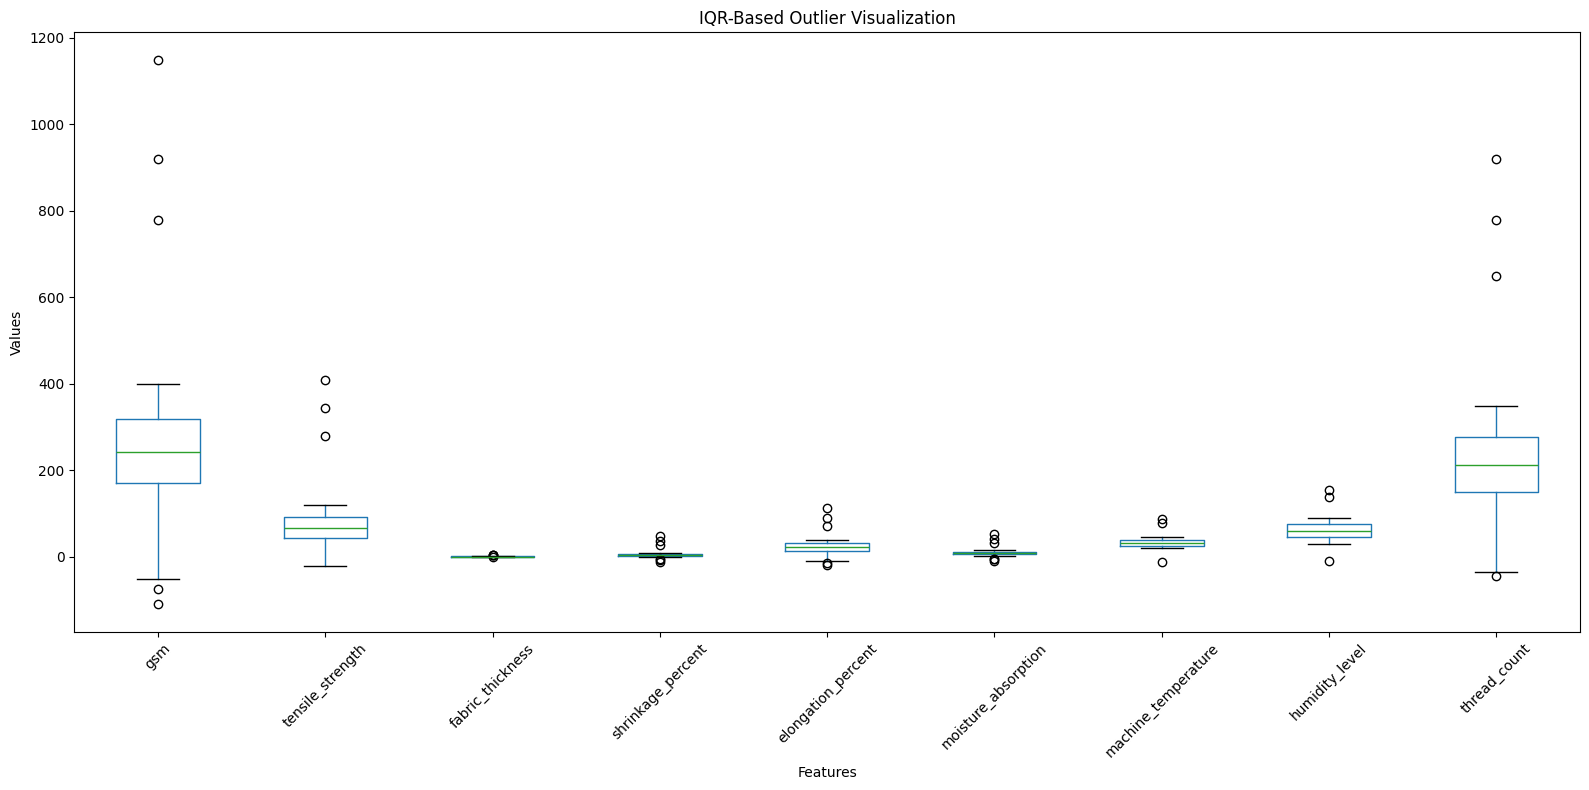

In [26]:
# ============================================================
# STEP 09A: FOCUSED OUTLIER VISUALIZATION
# ============================================================

outlier_features = [
    "gsm",
    "tensile_strength",
    "fabric_thickness",
    "shrinkage_percent",
    "elongation_percent",
    "moisture_absorption",
    "machine_temperature",
    "humidity_level",
    "thread_count"
]

plt.figure(figsize=(16, 8))

df[outlier_features].boxplot(
    rot=45,
    grid=False
)

plt.title("IQR-Based Outlier Visualization")
plt.xlabel("Features")
plt.ylabel("Values")

plt.tight_layout()
plt.show()

## STEP 10: Z-Score Outlier Detection

- Calculate Z-score for numerical features.
- Identify potential outliers using |Z| > 3.
- Compare the results with the IQR method.

### Z-Score Formula

**Z = (X − μ) / σ**

- X = Observed value
- μ = Mean
- σ = Standard Deviation
- **|Z| > 3 → Potential Outlier**


In [27]:
# ============================================================
# STEP 10: Z-SCORE OUTLIER DETECTION
# ============================================================

# Part 1: Store results
zscore_results = []

# Part 2: Calculate Z-score for each numerical feature
for col in numeric_features:

    mean_value = df[col].mean()
    std_value = df[col].std()

    z_scores = (df[col] - mean_value) / std_value

    # Part 3: Count potential outliers
    outlier_count = (z_scores.abs() > 3).sum()

    zscore_results.append([
        col,
        mean_value,
        std_value,
        outlier_count
    ])

# Part 4: Create summary table
zscore_summary = pd.DataFrame(
    zscore_results,
    columns=[
        "Feature",
        "Mean",
        "Standard Deviation",
        "Outlier Count"
    ]
)

# Part 5: Display results
display(zscore_summary)

,Feature,Mean,Standard Deviation,Outlier Count
0,thread_count,213.460253,76.212654,6
1,gsm,243.867202,87.655154,6
2,tensile_strength,67.597295,29.693005,4
3,shrinkage_percent,5.251848,2.698815,6
4,color_fastness,2.995162,1.414870,0
5,fabric_thickness,0.824942,0.392190,5
6,defect_count,7.008037,4.340864,0
7,elongation_percent,22.693089,10.158165,6
8,moisture_absorption,8.951134,3.486369,6
9,inspection_time_minutes,32.495750,15.906418,1


### IQR vs Z-Score Comparison

| Feature | IQR Outliers | Z-Score Outliers |
|---|---:|---:|
| thread_count | 4 | 6 |
| gsm | 5 | 6 |
| tensile_strength | 3 | 4 |
| shrinkage_percent | 6 | 6 |
| color_fastness | 0 | 0 |
| fabric_thickness | 4 | 5 |
| defect_count | 0 | 0 |
| elongation_percent | 5 | 6 |
| moisture_absorption | 6 | 6 |
| inspection_time_minutes | 0 | 1 |
| machine_temperature | 3 | 3 |
| humidity_level | 3 | 3 |

**Observation:**
- Both methods detected potential outliers in several features.
- Z-score detected slightly more outliers for some features.
- The difference occurs because IQR uses quartiles, while Z-score uses mean and standard deviation.
- Features with zero detected outliers require no outlier treatment based on these two methods.

## STEP 11: Outlier Treatment

- Remove observations identified as IQR-based outliers.
- Keep the cleaning decision consistent across numerical features.
- Verify the number of rows after outlier removal.

In [28]:
# ============================================================
# STEP 11: OUTLIER TREATMENT - REMOVE IQR OUTLIERS
# ============================================================

# Part 1: Store original row count
rows_before = len(df)

# Part 2: Create a mask for rows without IQR outliers
valid_rows = pd.Series(True, index=df.index)

for col in numeric_features:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Keep values inside the IQR bounds
    valid_rows &= (
        (df[col] >= lower_bound) &
        (df[col] <= upper_bound)
    )

# Part 3: Remove rows containing IQR outliers
df = df.loc[valid_rows].reset_index(drop=True)

# Part 4: Report changes
rows_after = len(df)
rows_removed = rows_before - rows_after

print("Rows Before Outlier Removal:", rows_before)
print("Rows After Outlier Removal:", rows_after)
print("Rows Removed:", rows_removed)


Rows Before Outlier Removal: 25008
Rows After Outlier Removal: 24969
Rows Removed: 39


### Outlier Treatment Observation

- 39 observations were identified as IQR-based outliers.
- These observations were removed from the dataset.
- The dataset now contains 24,969 records.

In [29]:
# ============================================================
# STEP 11A: VERIFY OUTLIER REMOVAL
# ============================================================

remaining_outliers = []

for col in numeric_features:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    remaining_outliers.append([col, count])

remaining_outliers = pd.DataFrame(
    remaining_outliers,
    columns=["Feature", "Remaining Outliers"]
)

display(remaining_outliers)

,Feature,Remaining Outliers
0,thread_count,0
1,gsm,0
2,tensile_strength,0
3,shrinkage_percent,0
4,color_fastness,0
5,fabric_thickness,0
6,defect_count,0
7,elongation_percent,0
8,moisture_absorption,0
9,inspection_time_minutes,0


## STEP 12: Data Transformation

- Check the skewness of numerical features.
- Identify highly skewed features.
- Apply a suitable transformation only where required.

In [30]:
# ============================================================
# STEP 12: CHECK SKEWNESS
# ============================================================

# Part 1: Calculate skewness for numerical features
skewness = df[numeric_features].skew()

# Part 2: Create a summary table
skewness_summary = pd.DataFrame({
    "Feature": skewness.index,
    "Skewness": skewness.values
})

# Part 3: Sort by absolute skewness
skewness_summary["Absolute Skewness"] = (
    skewness_summary["Skewness"].abs()
)

skewness_summary = skewness_summary.sort_values(
    "Absolute Skewness",
    ascending=False
)

# Part 4: Display result
display(skewness_summary)

,Feature,Skewness,Absolute Skewness
7,elongation_percent,-0.035710,0.035710
11,humidity_level,-0.027336,0.027336
8,moisture_absorption,0.020386,0.020386
0,thread_count,0.014865,0.014865
2,tensile_strength,-0.013837,0.013837
4,color_fastness,0.011930,0.011930
9,inspection_time_minutes,-0.007049,0.007049
3,shrinkage_percent,-0.005195,0.005195
10,machine_temperature,0.004981,0.004981
1,gsm,0.004435,0.004435


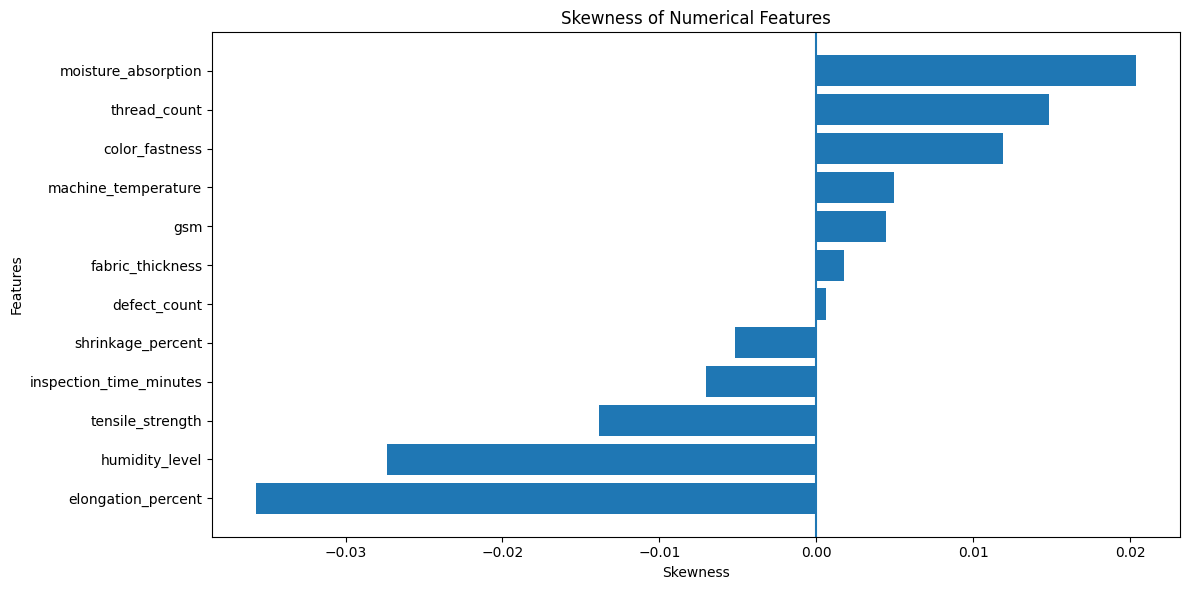

In [31]:
# ============================================================
# STEP 12A: SKEWNESS VISUALIZATION
# ============================================================

# Part 1: Sort features by skewness
plot_data = skewness_summary.sort_values("Skewness")

# Part 2: Plot skewness
plt.figure(figsize=(12, 6))

plt.barh(
    plot_data["Feature"],
    plot_data["Skewness"]
)

plt.axvline(0)

plt.title("Skewness of Numerical Features")
plt.xlabel("Skewness")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

### Skewness Observation

- All numerical features have skewness values close to zero.
- The distributions are approximately symmetric.
- No feature shows strong skewness.
- Therefore, log or square-root transformation is not required at this stage.

## STEP 13: Min-Max Normalization

- Scale numerical values to a range of 0 to 1.
- Implement the formula from scratch.
- Verify the transformed values.

In [32]:
# ============================================================
# STEP 13: MIN-MAX NORMALIZATION
# ============================================================

# Part 1: Select a numerical feature
feature = "gsm"

# Part 2: Calculate minimum and maximum
X_min = df[feature].min()
X_max = df[feature].max()

# Part 3: Apply Min-Max formula from scratch
df["gsm_normalized"] = (
    (df[feature] - X_min) /
    (X_max - X_min)
)

# Part 4: Display original vs normalized values
display(
    df[[feature, "gsm_normalized"]].head(10)
)

# Part 5: Verify range
print("Minimum normalized value:", df["gsm_normalized"].min())
print("Maximum normalized value:", df["gsm_normalized"].max())

,gsm,gsm_normalized
0,383.0,0.964365
1,107.0,0.349666
2,352.0,0.895323
3,200.0,0.556793
4,348.0,0.886414
5,387.0,0.973274
6,390.0,0.979955
7,370.0,0.935412
8,91.0,0.314031
9,286.0,0.748330


Minimum normalized value: 0.0
Maximum normalized value: 1.0


### Min-Max Normalization Formula

**X' = (X − Xmin) / (Xmax − Xmin)**

- X = Original value
- Xmin = Minimum value
- Xmax = Maximum value
- Result generally lies between 0 and 1.

### Normalization Observation

- The `gsm` feature was normalized using Min-Max normalization.
- The transformed values lie between 0 and 1.
- The original order of the observations is preserved.

## STEP 14: Standardization

- Standardize the `gsm` feature using mean and standard deviation.
- Implement the formula from scratch.
- Verify the transformed values.

In [34]:
# ============================================================
# STEP 14: STANDARDIZATION
# ============================================================

# Part 1: Select feature
feature = "gsm"

# Part 2: Calculate mean and standard deviation
mean_value = df[feature].mean()
std_value = df[feature].std()

# Part 3: Apply Standardization formula from scratch
df["gsm_standardized"] = (
    (df[feature] - mean_value) / std_value
)

# Part 4: Display original vs standardized values
display(
    df[[feature, "gsm_standardized"]].head(10)
)

# Part 5: Verify mean and standard deviation
print("Mean of standardized feature:",
      df["gsm_standardized"].mean())

print("Standard deviation of standardized feature:",
      df["gsm_standardized"].std())

,gsm,gsm_standardized
0,383.0,1.594799
1,107.0,-1.568198
2,352.0,1.239535
3,200.0,-0.502405
4,348.0,1.193694
5,387.0,1.640640
6,390.0,1.675020
7,370.0,1.445817
8,91.0,-1.751560
9,286.0,0.483166


Mean of standardized feature: -1.4619781749239115e-16
Standard deviation of standardized feature: 1.000000000000001


### Standardization Formula

**Z = (X − μ) / σ**

- X = Original value
- μ = Mean
- σ = Standard deviation
- Standardized data is centered around 0.

### Standardization Observation

- `gsm` was standardized using its mean and standard deviation.
- The transformed feature has mean approximately 0.
- The standard deviation is approximately 1.
- Values can be negative or positive after standardization.

## STEP 15: Normalization vs Standardization

- Compare the two scaling techniques.
- Understand their output ranges and use cases.
- Summarize the difference in a comparison table.

In [35]:
# ============================================================
# STEP 15: NORMALIZATION VS STANDARDIZATION
# ============================================================

comparison = pd.DataFrame({
    "Aspect": [
        "Formula",
        "Output",
        "Main Purpose",
        "Range",
        "Effect of Outliers"
    ],
    "Min-Max Normalization": [
        "(X - Xmin) / (Xmax - Xmin)",
        "Rescales values",
        "Bring values to a common range",
        "Usually 0 to 1",
        "More sensitive to extreme values"
    ],
    "Standardization": [
        "(X - μ) / σ",
        "Centers and scales values",
        "Make mean 0 and SD 1",
        "No fixed range",
        "Generally less affected than Min-Max"
    ]
})

display(comparison)

,Aspect,Min-Max Normalization,Standardization
0,Formula,(X - Xmin) / (Xmax - Xmin),(X - μ) / σ
1,Output,Rescales values,Centers and scales values
2,Main Purpose,Bring values to a common range,Make mean 0 and SD 1
3,Range,Usually 0 to 1,No fixed range
4,Effect of Outliers,More sensitive to extreme values,Generally less affected than Min-Max
